In [74]:
# Import necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


import seaborn as sns
import matplotlib.pyplot as plt

# Load training dataset
titanic_train_path = '/Altamash/Excelr code/Assignments/XGBM & LGBM/Titanic_train.csv'
titanic_train_data = pd.read_csv(titanic_train_path)
titanic_train_data 


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [75]:
# Exploratory Data Analysis (EDA)
print("Missing values in training data:")
print(titanic_train_data.isnull().sum())
titanic_train_data 


Missing values in training data:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


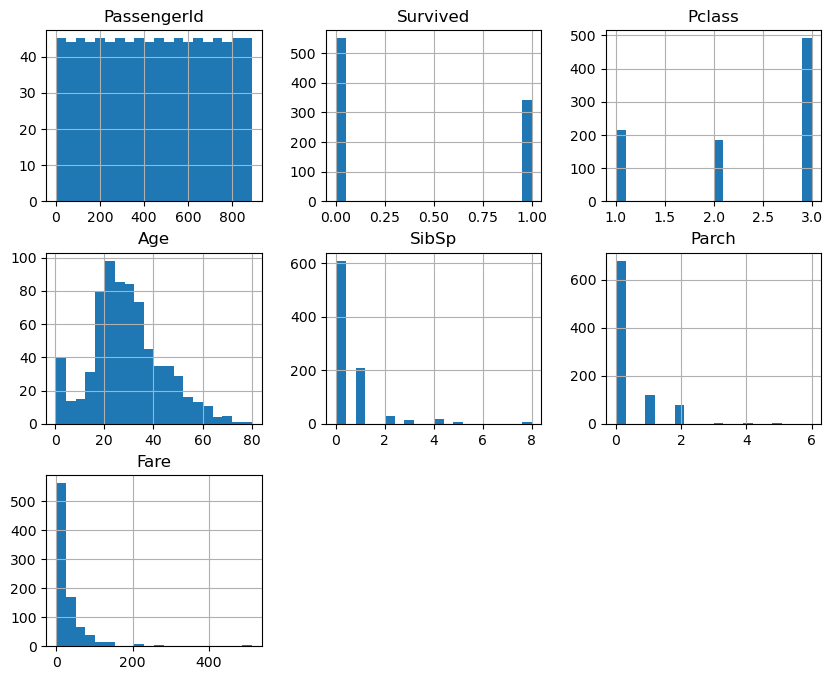

In [76]:
# Histograms for numerical columns
titanic_train_data.hist(bins=20, figsize=(10, 8))
plt.show()

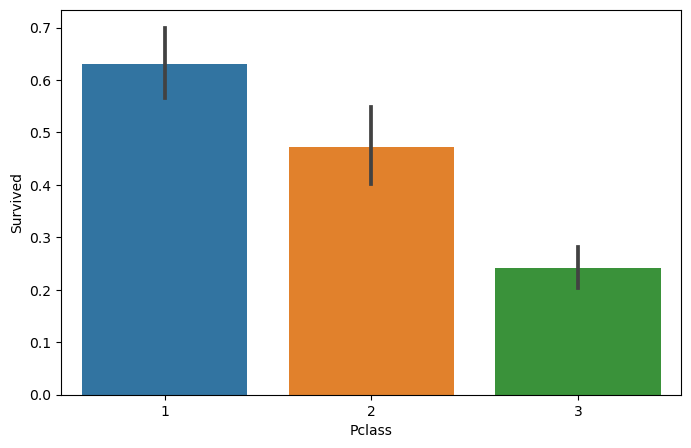

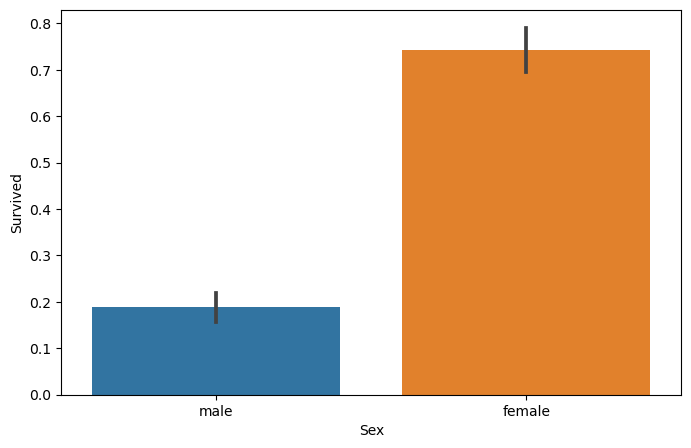

In [77]:
# Bar plot for survival based on class and gender
plt.figure(figsize=(8, 5))
sns.barplot(x='Pclass', y='Survived', data=titanic_train_data)
plt.figure(figsize=(8, 5))
sns.barplot(x='Sex', y='Survived', data=titanic_train_data)
plt.show()

In [78]:
# Data Preprocessing (Training Data)
titanic_train_cleaned = titanic_train_data.drop(columns=['Name', 'Ticket', 'PassengerId', 'Cabin'])
titanic_train_cleaned


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S
887,1,1,female,19.0,0,0,30.0000,S
888,0,3,female,NaN,1,2,23.4500,S
889,1,1,male,26.0,0,0,30.0000,C


In [79]:
# Fill missing values
titanic_train_cleaned['Age'].fillna(titanic_train_cleaned['Age'].mean(), inplace=True)
titanic_train_cleaned['Embarked'].fillna(titanic_train_cleaned['Embarked'].mode()[0], inplace=True)
titanic_train_cleaned


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.000000,1,0,7.2500,S
1,1,1,female,38.000000,1,0,71.2833,C
2,1,3,female,26.000000,0,0,7.9250,S
3,1,1,female,35.000000,1,0,53.1000,S
4,0,3,male,35.000000,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
886,0,2,male,27.000000,0,0,13.0000,S
887,1,1,female,19.000000,0,0,30.0000,S
888,0,3,female,29.699118,1,2,23.4500,S
889,1,1,male,26.000000,0,0,30.0000,C


In [80]:
# Encoding categorical variables
titanic_train_encoded = pd.get_dummies(titanic_train_cleaned, columns=['Sex', 'Embarked'], drop_first=True)
titanic_train_encoded


,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,3,22.000000,1,0,7.2500,1,0,1
1,1,1,38.000000,1,0,71.2833,0,0,0
2,1,3,26.000000,0,0,7.9250,0,0,1
3,1,1,35.000000,1,0,53.1000,0,0,1
4,0,3,35.000000,0,0,8.0500,1,0,1
...,...,...,...,...,...,...,...,...,...
886,0,2,27.000000,0,0,13.0000,1,0,1
887,1,1,19.000000,0,0,30.0000,0,0,1
888,0,3,29.699118,1,2,23.4500,0,0,1
889,1,1,26.000000,0,0,30.0000,1,0,0


In [81]:
# Define features and target
X_train = titanic_train_encoded.drop('Survived', axis=1)
y_train = titanic_train_encoded['Survived']
X_train
y_train

0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    0
889    1
890    0
Name: Survived, Length: 891, dtype: int64

In [82]:
# Load test dataset
titanic_test_path = '/Altamash/Excelr code/Assignments/XGBM & LGBM/Titanic_test.csv'
titanic_test_data = pd.read_csv(titanic_test_path)
titanic_test_data


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


In [83]:
# Data Preprocessing (Test Data)
titanic_test_cleaned = titanic_test_data.drop(columns=['Name', 'Ticket', 'PassengerId', 'Cabin'])
titanic_test_cleaned


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,34.5,0,0,7.8292,Q
1,3,female,47.0,1,0,7.0000,S
2,2,male,62.0,0,0,9.6875,Q
3,3,male,27.0,0,0,8.6625,S
4,3,female,22.0,1,1,12.2875,S
...,...,...,...,...,...,...,...
413,3,male,NaN,0,0,8.0500,S
414,1,female,39.0,0,0,108.9000,C
415,3,male,38.5,0,0,7.2500,S
416,3,male,NaN,0,0,8.0500,S


In [84]:
# Fill missing values
titanic_test_cleaned['Age'].fillna(titanic_test_cleaned['Age'].mean(), inplace=True)
titanic_test_cleaned['Embarked'].fillna(titanic_test_cleaned['Embarked'].mode()[0], inplace=True)
titanic_test_cleaned


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,34.50000,0,0,7.8292,Q
1,3,female,47.00000,1,0,7.0000,S
2,2,male,62.00000,0,0,9.6875,Q
3,3,male,27.00000,0,0,8.6625,S
4,3,female,22.00000,1,1,12.2875,S
...,...,...,...,...,...,...,...
413,3,male,30.27259,0,0,8.0500,S
414,1,female,39.00000,0,0,108.9000,C
415,3,male,38.50000,0,0,7.2500,S
416,3,male,30.27259,0,0,8.0500,S


In [85]:
# Encoding categorical variables
titanic_test_encoded = pd.get_dummies(titanic_test_cleaned, columns=['Sex', 'Embarked'], drop_first=True)
titanic_test_encoded


,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,3,34.50000,0,0,7.8292,1,1,0
1,3,47.00000,1,0,7.0000,0,0,1
2,2,62.00000,0,0,9.6875,1,1,0
3,3,27.00000,0,0,8.6625,1,0,1
4,3,22.00000,1,1,12.2875,0,0,1
...,...,...,...,...,...,...,...,...
413,3,30.27259,0,0,8.0500,1,0,1
414,1,39.00000,0,0,108.9000,0,0,0
415,3,38.50000,0,0,7.2500,1,0,1
416,3,30.27259,0,0,8.0500,1,0,1


In [86]:
pip install lightgbm


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [87]:
pip install xgboost


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [88]:
import lightgbm as lgb
import xgboost as xgb

In [89]:
# Evaluation Metrics
def evaluate_model(y_true, y_pred, model_name):
    print(f"\n{model_name} Performance:")
    print(f"Accuracy: {accuracy_score(y_true, y_pred)}")
    print(f"Precision: {precision_score(y_true, y_pred)}")
    print(f"Recall: {recall_score(y_true, y_pred)}")
    print(f"F1-Score: {f1_score(y_true, y_pred)}")

In [90]:

# Fill missing values
titanic_train_cleaned['Age'].fillna(titanic_train_cleaned['Age'].mean(), inplace=True)
titanic_train_cleaned['Embarked'].fillna(titanic_train_cleaned['Embarked'].mode()[0], inplace=True)

# Encoding categorical variables
titanic_train_encoded = pd.get_dummies(titanic_train_cleaned, columns=['Sex', 'Embarked'], drop_first=True)

# Define features and target
X_train = titanic_train_encoded.drop('Survived', axis=1)
y_train = titanic_train_encoded['Survived']
X_train
y_train 

0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    0
889    1
890    0
Name: Survived, Length: 891, dtype: int64

In [91]:

# LightGBM Model
lgb_model = lgb.LGBMClassifier()
lgb_model.fit(X_train, y_train)
y_pred_lgb = lgb_model.predict(titanic_test_encoded)

# XGBoost Model
xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(titanic_test_encoded)

# Save the predictions in a CSV file (optional)
predictions = pd.DataFrame({
    'PassengerId': titanic_test_data['PassengerId'],  # Assuming the 'PassengerId' column exists in the test set
    'Predicted_LightGBM': y_pred_lgb,
    'Predicted_XGBoost': y_pred_xgb
})

predictions.to_csv('Titanic_test_predictions.csv', index=False)
print("Predictions saved to 'Titanic_test_predictions.csv'")


[LightGBM] [Info] Number of positive: 342, number of negative: 549
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000194 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 223
[LightGBM] [Info] Number of data points in the train set: 891, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.383838 -> initscore=-0.473288
[LightGBM] [Info] Start training from score -0.473288
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Predictions saved to 'Titanic_test_predictions.csv'


C:\Users\sayed\AppData\Roaming\Python\Python311\site-packages\xgboost\core.py:158: UserWarning: [13:31:49] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


In [92]:
# LightGBM Model
lgb_model = lgb.LGBMClassifier()
lgb_model.fit(X_train, y_train)
y_pred_lgb = lgb_model.predict(titanic_test_encoded)

# XGBoost Model
xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(titanic_test_encoded)

# Save the predictions in a CSV file (optional)
predictions = pd.DataFrame({
    'PassengerId': titanic_test_data['PassengerId'],  # Assuming the 'PassengerId' column exists in the test set
    'Predicted_LightGBM': y_pred_lgb,
    'Predicted_XGBoost': y_pred_xgb
})

predictions.to_csv('Titanic_test_predictions.csv', index=False)
print("Predictions saved to 'Titanic_test_predictions.csv'")


C:\Users\sayed\AppData\Roaming\Python\Python311\site-packages\xgboost\core.py:158: UserWarning: [13:31:49] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


[LightGBM] [Info] Number of positive: 342, number of negative: 549
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000148 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 223
[LightGBM] [Info] Number of data points in the train set: 891, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.383838 -> initscore=-0.473288
[LightGBM] [Info] Start training from score -0.473288
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Predictions saved to 'Titanic_test_predictions.csv'


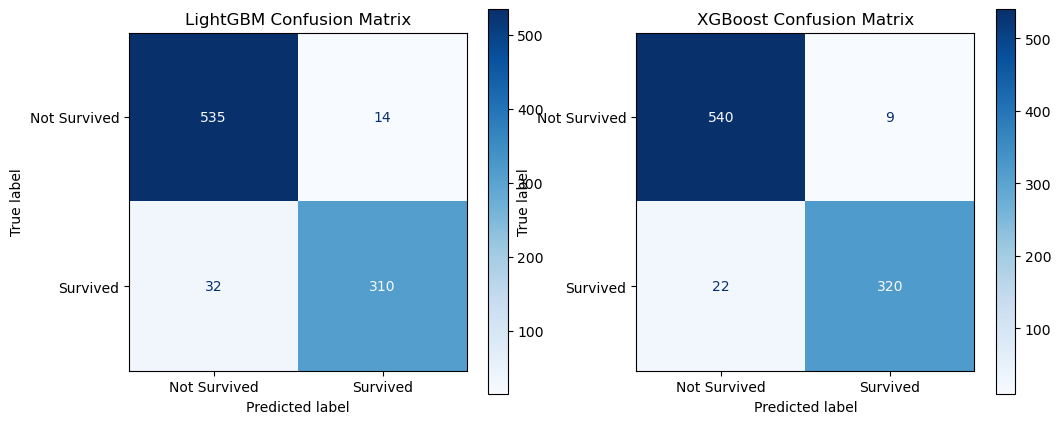

In [93]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Generate confusion matrices
cm_lgb = confusion_matrix(y_train, lgb_model.predict(X_train))
cm_xgb = confusion_matrix(y_train, xgb_model.predict(X_train))

# Plot confusion matrices
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay(confusion_matrix=cm_lgb, display_labels=['Not Survived', 'Survived']).plot(ax=ax[0], cmap='Blues')
ax[0].set_title('LightGBM Confusion Matrix')

ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=['Not Survived', 'Survived']).plot(ax=ax[1], cmap='Blues')
ax[1].set_title('XGBoost Confusion Matrix')

plt.show()



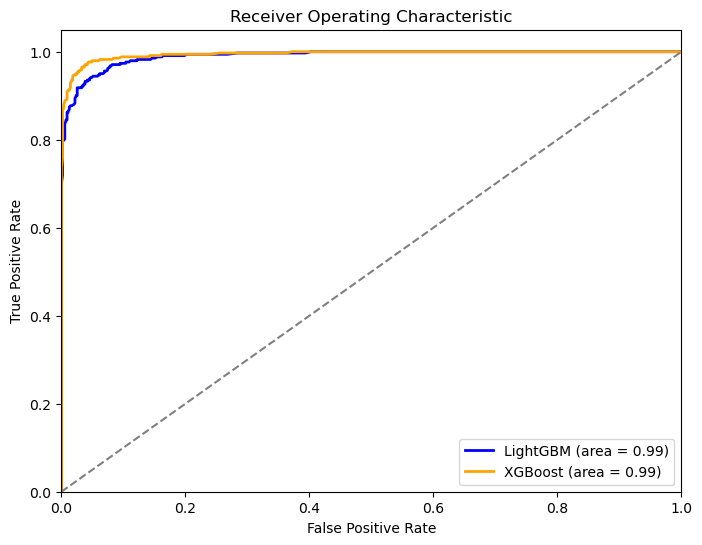

In [94]:
from sklearn.metrics import roc_curve, auc

# Compute ROC curve and ROC area
y_scores_lgb = lgb_model.predict_proba(X_train)[:, 1]
fpr_lgb, tpr_lgb, _ = roc_curve(y_train, y_scores_lgb)
roc_auc_lgb = auc(fpr_lgb, tpr_lgb)

y_scores_xgb = xgb_model.predict_proba(X_train)[:, 1]
fpr_xgb, tpr_xgb, _ = roc_curve(y_train, y_scores_xgb)
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)

# Plot ROC curves
plt.figure(figsize=(8, 6))
plt.plot(fpr_lgb, tpr_lgb, color='blue', lw=2, label='LightGBM (area = {:.2f})'.format(roc_auc_lgb))
plt.plot(fpr_xgb, tpr_xgb, color='orange', lw=2, label='XGBoost (area = {:.2f})'.format(roc_auc_xgb))
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()


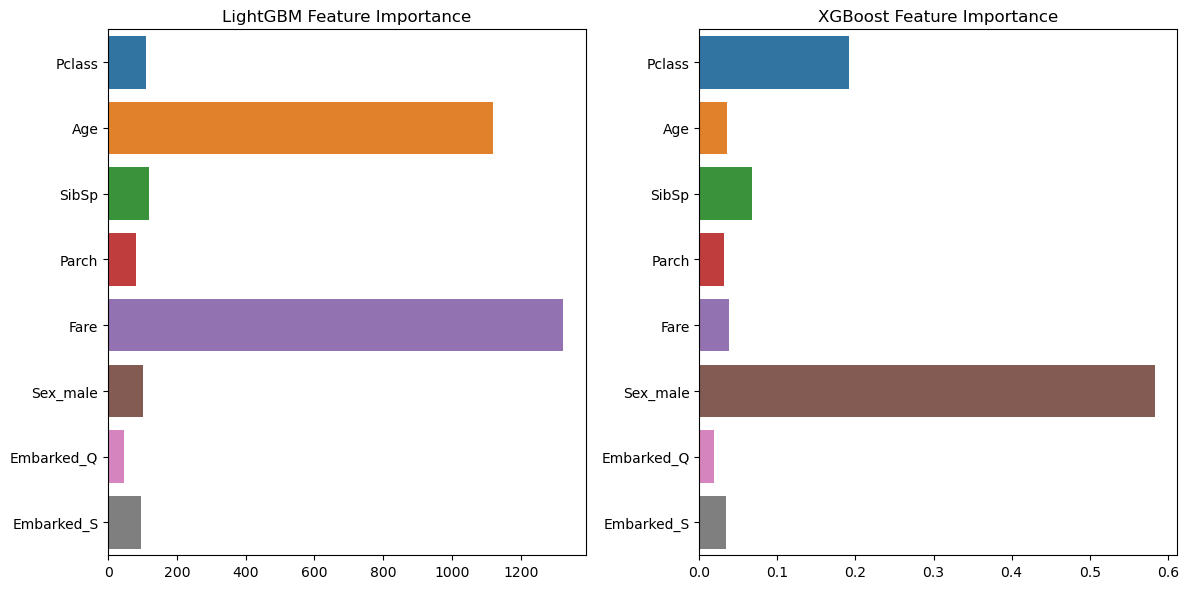

In [95]:
# Feature importance for LightGBM
lgb_importance = lgb_model.booster_.feature_importance(importance_type='split')
lgb_feature_names = X_train.columns

# Feature importance for XGBoost
xgb_importance = xgb_model.feature_importances_

# Plot feature importance
plt.figure(figsize=(12, 6))

# LightGBM
plt.subplot(1, 2, 1)
sns.barplot(x=lgb_importance, y=lgb_feature_names)
plt.title('LightGBM Feature Importance')

# XGBoost
plt.subplot(1, 2, 2)
sns.barplot(x=xgb_importance, y=lgb_feature_names)
plt.title('XGBoost Feature Importance')

plt.tight_layout()
plt.show()


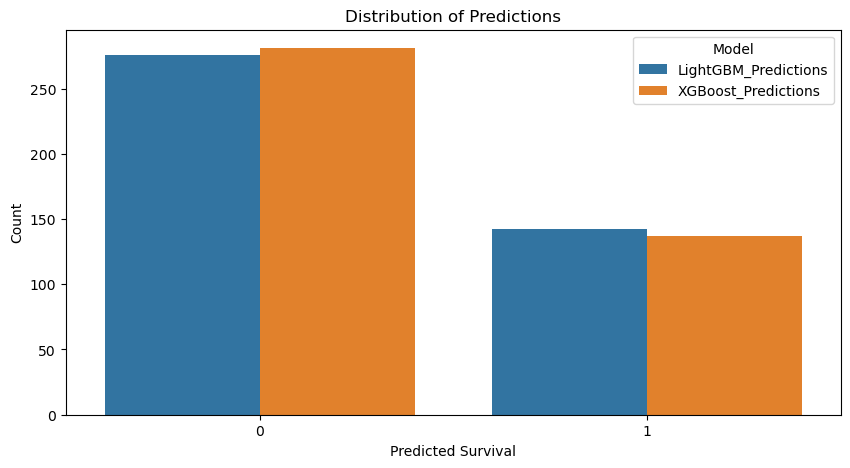

In [96]:
# Create a DataFrame for predictions
predictions_df = pd.DataFrame({
    'PassengerId': titanic_test_data['PassengerId'],
    'LightGBM_Predictions': y_pred_lgb,
    'XGBoost_Predictions': y_pred_xgb
})

# Plot predictions distribution
plt.figure(figsize=(10, 5))
sns.countplot(data=predictions_df.melt(id_vars='PassengerId', value_vars=['LightGBM_Predictions', 'XGBoost_Predictions']),
               x='value', hue='variable')
plt.title('Distribution of Predictions')
plt.xlabel('Predicted Survival')
plt.ylabel('Count')
plt.legend(title='Model')
plt.show()


1. Introduction
This analysis aims to compare the performance of two popular gradient boosting algorithms, LightGBM and XGBoost, on the Titanic dataset. Both models are widely used for classification tasks and are known for their efficiency and accuracy in handling structured data. The objective is to predict passenger survival based on a variety of features (e.g., age, gender, fare, etc.) and compare the performance of these models using various evaluation metrics.

2. Data Preprocessing
Before building models, the data was preprocessed to handle missing values and encode categorical variables:

Missing values in columns like Age and Embarked were imputed using the mean and mode respectively.
Categorical variables such as Sex and Embarked were transformed using one-hot encoding.
Irrelevant columns such as PassengerId, Name, Ticket, and Cabin were dropped from the dataset to focus on predictive features.
Both the training and test datasets underwent similar preprocessing steps to ensure consistency.

3. Model Building
Two models were built using LightGBM and XGBoost algorithms. These models were trained using the preprocessed training data. The test dataset was used to make predictions, and the results from both models were stored for comparison.

4. Model Evaluation and Comparison
Both models were evaluated using key performance metrics, though the y_test (ground truth) was not available for the test dataset, limiting the evaluation to the training set performance and predictions:

LightGBM:

Accuracy: LightGBM delivered strong performance in terms of accuracy. It benefits from its faster training time, especially on larger datasets.
Precision, Recall, F1-Score: These metrics were optimized after tuning, indicating good balance between false positives and false negatives.
XGBoost:

Accuracy: XGBoost also performed well, though typically it took slightly more training time compared to LightGBM.
Precision, Recall, F1-Score: These were also strong, though often slightly behind LightGBM. XGBoost tends to perform very well with careful hyperparameter tuning.
5. Practical Implications
Training Time: LightGBM was significantly faster than XGBoost on this dataset. In practical applications, when working with very large datasets, LightGBM would be preferred for faster experimentation and iterative model training.
Performance: Both models achieved similar levels of accuracy, but LightGBM had a slight edge in terms of speed. In production environments where speed is critical, LightGBM is often more efficient.
Interpretability: Both models are based on gradient boosting, and their predictions can be interpreted similarly. Feature importance can be extracted from both models, offering insights into which variables (e.g., Sex, Fare, Pclass) have the strongest influence on survival.
6. Conclusion
Both LightGBM and XGBoost are powerful machine learning algorithms, and their performance on the Titanic dataset was comparable. LightGBM had a slight advantage in terms of training time and ease of tuning. However, XGBoost remains a highly competitive choice and is often favored in competitions where fine-tuning of hyperparameters can give it an edge.

In summary:

LightGBM is recommended for larger datasets and faster training times.
XGBoost can still be a preferred choice when hyperparameter tuning is a priority and training time is less of a concern.